## Hecho por: Lucian Valle Aguilar
## C.C 1066866114

In [1]:
import sklearn
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
import seaborn as sns
from scipy import stats
from scipy import optimize
from scipy.stats import norm
from matplotlib import cm
from scipy.stats import multivariate_normal
from sklearn.model_selection import train_test_split
#Machinig learning models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import ShuffleSplit

## 1. Entrenamiento de modelos

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def make_meshgrid(x, y, h=0.02):
    """Crea una malla de puntos para graficar la frontera de decisión."""
    x_min, x_max = x.min() - 1, x.max() + 1
    y_min, y_max = y.min() - 1, y.max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    return xx, yy

def plot_contours(ax, clf, xx, yy, **params):
    """Dibuja los contornos de decisión de un clasificador."""
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    out = ax.contourf(xx, yy, Z, **params)
    return out

In [3]:
def data( mu=[1,1], mu1=[-2,2], cov=[[1.0, 0.0], [0.0, 1.0]] , cov1= [[1.0, -0.5], [-0.5, 1.0]]   ):# Caso mas visible
  rv = multivariate_normal(mu, cov)
  rv1 = multivariate_normal(mu1, cov1)
  return rv, rv1

def sample(N1= 1000, N2 = 100, r = 0.2):
  X_t = np.concatenate([rv.rvs(N1, random_state = r  ), rv1.rvs(N2,random_state = r)]) # Todos los datos en la misma distribución,
  y   = np.concatenate([np.zeros(N1), np.ones(N2) ]  )
  return X_t, y


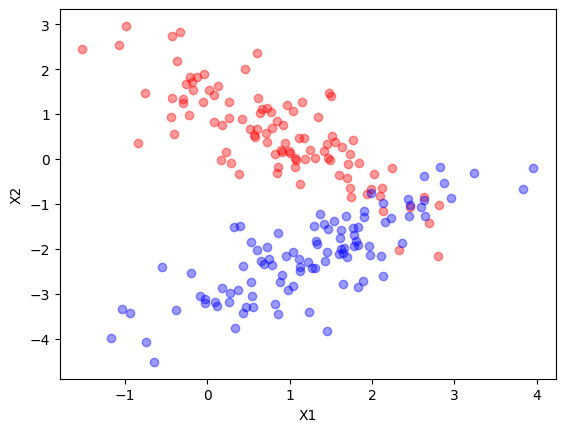

In [4]:
rv, rv1 = data( mu=[1,0.4], mu1=[1.4,-2],
     cov=[[1.0, -0.8], [-0.8, 1.0]] ,
     cov1= [[1.0, 0.8], [0.8, 1.0]])
X_t, y = sample(N1 = 100, N2 = 100, r = 10)

plt.plot(X_t[y==0][:,0],X_t[y==0][:,1],"ro", alpha=0.4)
plt.plot(X_t[y==1][:,0],X_t[y==1][:,1],"bo", alpha=0.4)
plt.xlabel("X1")
plt.ylabel("X2")
plt.show()

Accuracy del modelo: 0.9400


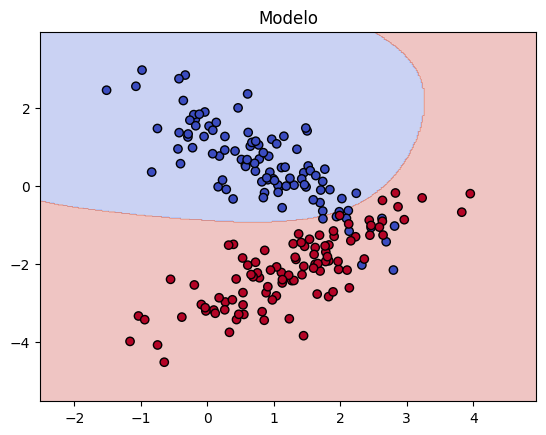

In [5]:
from sklearn.svm import SVC

gamma_val = 'scale'
model = SVC(kernel='rbf', gamma=gamma_val, C=1.0)

model.fit(X_t, y)

score = model.score(X_t, y)
print(f"Accuracy del modelo: {score:.4f}")

def plot_decision_boundary(model, X, y, title="Modelo"):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors='k')
    plt.title(title)
    plt.show()

plot_decision_boundary(model, X_t, y)

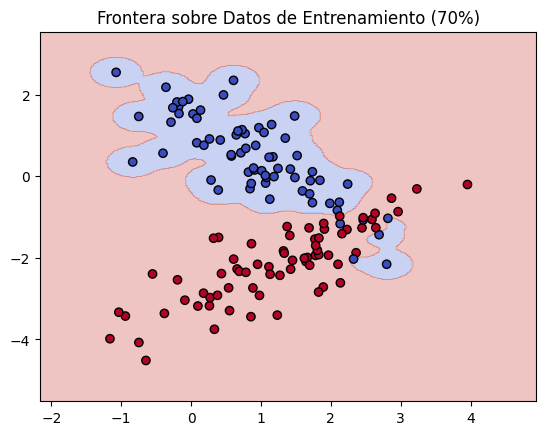

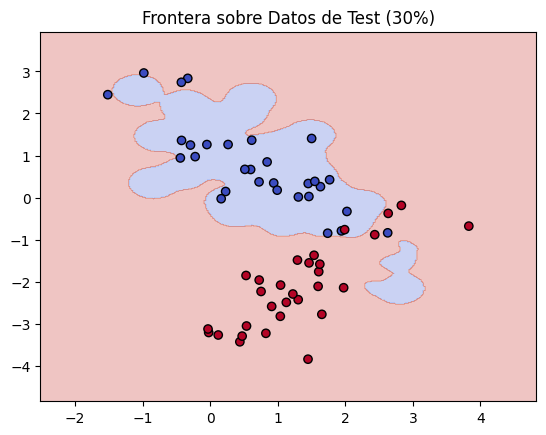

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X_t, y, test_size=0.3, random_state=1)

clf = SVC(gamma=20.0)
clf.fit(X_train, y_train)

plot_decision_boundary(clf, X_train, y_train, title="Frontera sobre Datos de Entrenamiento (70%)")

plot_decision_boundary(clf, X_test, y_test, title="Frontera sobre Datos de Test (30%)")

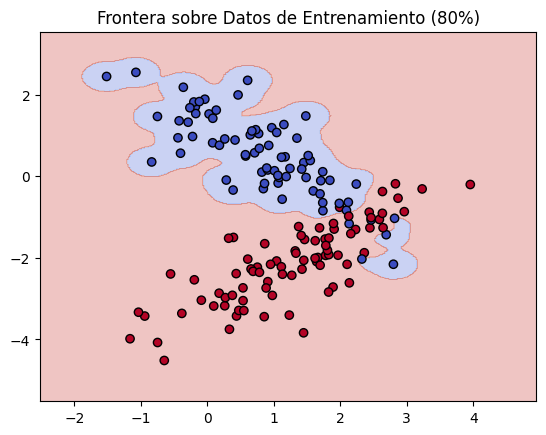

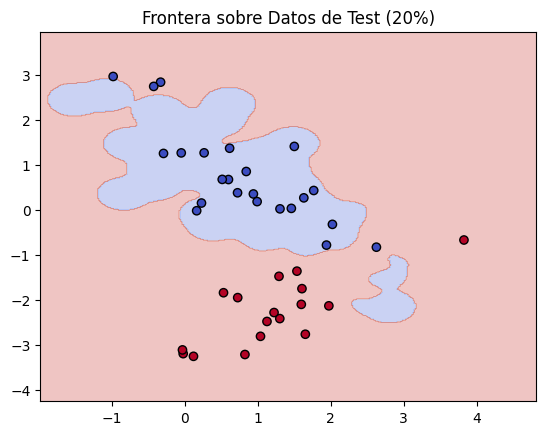

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X_t, y, test_size=0.2, random_state=1)

clf = SVC(gamma=20.0)
clf.fit(X_train, y_train)

plot_decision_boundary(clf, X_train, y_train, title="Frontera sobre Datos de Entrenamiento (80%)")

plot_decision_boundary(clf, X_test, y_test, title="Frontera sobre Datos de Test (20%)")

## 2. Curvas de aprendizaje

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.svm import SVC

X_train_cv, X_test, y_train_cv, y_test = train_test_split(
    X_t, y, test_size=0.20, random_state=1
)

param_range = np.logspace(-3, 2, 20)
param_grid = {'gamma': param_range}

grid_search = GridSearchCV(SVC(kernel='rbf'), param_grid, cv=8, scoring='accuracy')
grid_search.fit(X_train_cv, y_train_cv)

best_gamma = grid_search.best_params_['gamma']
print(f"Mejor parámetro gamma según GridSearch: {best_gamma:.4f}")
print(f"Score en Test (20% restante): {grid_search.score(X_test, y_test):.3f}")

Mejor parámetro gamma según GridSearch: 0.7848
Score en Test (20% restante): 0.950


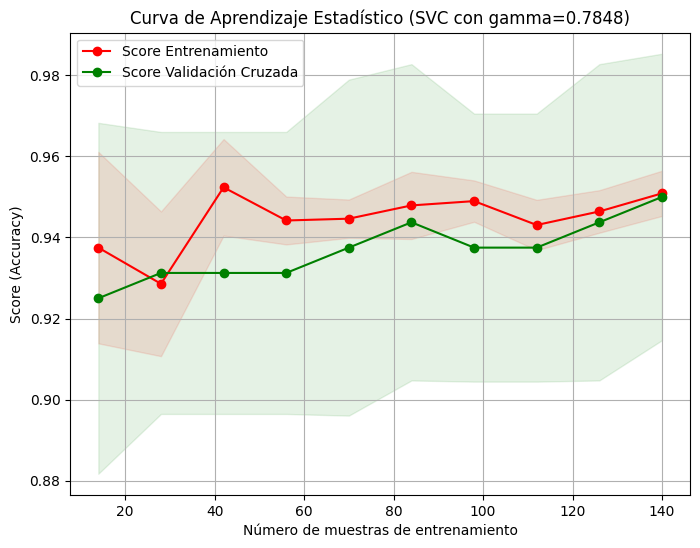

In [9]:
best_model = SVC(kernel='rbf', gamma=best_gamma)

train_sizes, train_scores, val_scores = learning_curve(
    best_model,
    X_train_cv,
    y_train_cv,
    cv=8,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='accuracy',
    n_jobs=-1
)

# Promedios y desviaciones estándar para graficar
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

# Graficar las curvas de aprendizaje
plt.figure(figsize=(8, 6))

# Línea de entrenamiento
plt.plot(train_sizes, train_mean, 'o-', color="r", label="Score Entrenamiento")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="r")

# Línea de validación cruzada
plt.plot(train_sizes, val_mean, 'o-', color="g", label="Score Validación Cruzada")
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1, color="g")

plt.title(f"Curva de Aprendizaje Estadístico (SVC con gamma={best_gamma:.4f})")
plt.xlabel("Número de muestras de entrenamiento")
plt.ylabel("Score (Accuracy)")
plt.legend(loc="best")
plt.grid(True)
plt.show()

## 3. Underfitting y Overfitting



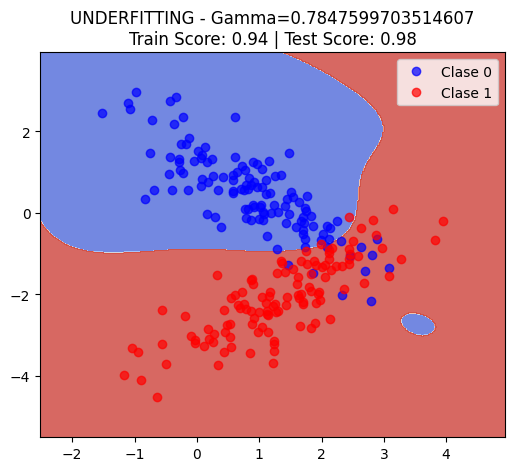

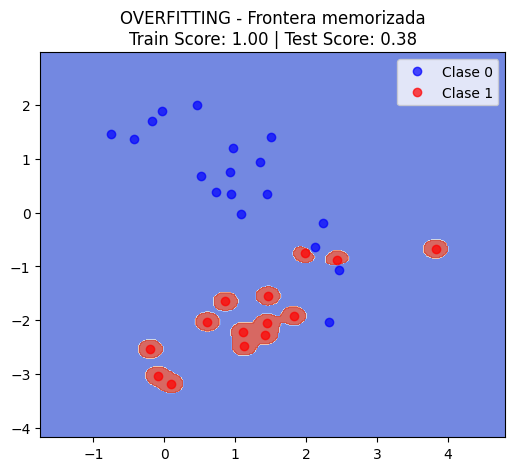

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split


best_gamma = best_gamma

# --------------------------------------------------------------------------
# 1. CASO UNDERFITTING
# --------------------------------------------------------------------------
mu_under_0 = [0.0, 0.0]
mu_under_1 = [0.2, 0.2]
cov_under_0 = [[4.0, 0], [0, 4.0]]
cov_under_1 = [[4.0, 0], [0, 4.0]]

rv_u0, rv_u1 = data(mu=mu_under_0, mu1=mu_under_1, cov=cov_under_0, cov1=cov_under_1)
X_under, y_under = sample(N1=150, N2=150, r=10)

X_tr_u, X_te_u, y_tr_u, y_te_u = train_test_split(X_under, y_under, test_size=0.2, random_state=1)

clf_under = SVC(kernel='rbf', gamma=best_gamma)
clf_under.fit(X_tr_u, y_tr_u)

fig, ax = plt.subplots(figsize=(6, 5))
xx, yy = make_meshgrid(X_tr_u[:, 0], X_tr_u[:, 1])
plot_contours(ax, clf_under, xx, yy, cmap=plt.cm.coolwarm, alpha=0.8)
plt.plot(X_tr_u[y_tr_u==0][:,0], X_tr_u[y_tr_u==0][:,1], "bo", alpha=0.7, label="Clase 0")
plt.plot(X_tr_u[y_tr_u==1][:,0], X_tr_u[y_tr_u==1][:,1], "ro", alpha=0.7, label="Clase 1")
plt.title(f"UNDERFITTING - Gamma={best_gamma}\nTrain Score: {clf_under.score(X_tr_u, y_tr_u):.2f} | Test Score: {clf_under.score(X_te_u, y_te_u):.2f}")
plt.legend()
plt.show()

# --------------------------------------------------------------------------
# 2. CASO OVERFITTING
# --------------------------------------------------------------------------
mu_over_0 = [-1.0, -1.0]
mu_over_1 = [1.0, 1.0]
cov_over_0 = [[0.8, -0.6], [-0.6, 0.8]]
cov_over_1 = [[0.8, 0.6], [0.6, 0.8]]

rv_o0, rv_o1 = data(mu=mu_over_0, mu1=mu_over_1, cov=cov_over_0, cov1=cov_over_1)
X_over, y_over = sample(N1=20, N2=20, r=10)

X_tr_o, X_te_o, y_tr_o, y_te_o = train_test_split(X_over, y_over, test_size=0.2, random_state=1)

clf_over = SVC(kernel='rbf', gamma=50.0)
clf_over.fit(X_tr_o, y_tr_o)

fig, ax = plt.subplots(figsize=(6, 5))
xx, yy = make_meshgrid(X_tr_o[:, 0], X_tr_o[:, 1])
plot_contours(ax, clf_over, xx, yy, cmap=plt.cm.coolwarm, alpha=0.8)
plt.plot(X_tr_o[y_tr_o==0][:,0], X_tr_o[y_tr_o==0][:,1], "bo", alpha=0.7, label="Clase 0")
plt.plot(X_tr_o[y_tr_o==1][:,0], X_tr_o[y_tr_o==1][:,1], "ro", alpha=0.7, label="Clase 1")
plt.title(f"OVERFITTING - Frontera memorizada\nTrain Score: {clf_over.score(X_tr_o, y_tr_o):.2f} | Test Score: {clf_over.score(X_te_o, y_te_o):.2f}")
plt.legend()
plt.show()